In [30]:
import numpy as np
import pandas as pd

import seaborn as sns
import math
import sklearn.preprocessing
import sklearn.linear_model
import sklearn.metrics
import sklearn.neighbors
from sklearn.preprocessing import StandardScaler

from sklearn.model_selection import train_test_split

from IPython.display import display

In [2]:
df = pd.read_csv('../data/insurance_us.csv')

In [3]:
df = df.rename(columns={'Gender': 'gender', 'Age': 'age', 'Salary': 'income', 'Family members': 'family_members', 'Insurance benefits': 'insurance_benefits'})

In [4]:
df.sample(10)

,gender,age,income,family_members,insurance_benefits
4077,1,23.0,46900.0,0,0
4534,0,34.0,41500.0,0,0
188,0,29.0,37400.0,3,0
1366,0,38.0,36600.0,0,0
4541,1,35.0,52100.0,1,0
1530,0,32.0,45100.0,1,0
4382,0,26.0,26300.0,2,0
4018,0,22.0,48200.0,2,0
4719,1,38.0,26400.0,4,0
1276,1,23.0,41900.0,2,0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   gender              5000 non-null   int64  
 1   age                 5000 non-null   float64
 2   income              5000 non-null   float64
 3   family_members      5000 non-null   int64  
 4   insurance_benefits  5000 non-null   int64  
dtypes: float64(2), int64(3)
memory usage: 195.4 KB


In [6]:
# podemos querer corrigir o tipo de idade (de float para int), embora isso não seja crítico

df['age'] = df['age'].astype(int)
# escreva sua conversão aqui se você escolher:
# - alterando age para int, facilitando a visualização da distribuição de idades

In [7]:
# verifique se a conversão foi bem-sucedida
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   gender              5000 non-null   int64  
 1   age                 5000 non-null   int64  
 2   income              5000 non-null   float64
 3   family_members      5000 non-null   int64  
 4   insurance_benefits  5000 non-null   int64  
dtypes: float64(1), int64(4)
memory usage: 195.4 KB


In [11]:
# agora dê uma olhada nas estatísticas descritivas dos dados.
print(df.describe())
# Parece que está tudo bem?

            gender          age        income  family_members  \
count  5000.000000  5000.000000   5000.000000     5000.000000   
mean      0.499000    30.952800  39916.360000        1.194200   
std       0.500049     8.440807   9900.083569        1.091387   
min       0.000000    18.000000   5300.000000        0.000000   
25%       0.000000    24.000000  33300.000000        0.000000   
50%       0.000000    30.000000  40200.000000        1.000000   
75%       1.000000    37.000000  46600.000000        2.000000   
max       1.000000    65.000000  79000.000000        6.000000   

       insurance_benefits  
count         5000.000000  
mean             0.148000  
std              0.463183  
min              0.000000  
25%              0.000000  
50%              0.000000  
75%              0.000000  
max              5.000000  


- Não há valores nulos ou inconsistências.
- As distribuições são plausíveis.
- A variável target é desbalanceada.
- Será necessário normalizar os dados para modelos baseados em distância.

## AED

Vamos verificar rapidamente se existem determinados grupos de clientes observando o gráfico de pares.

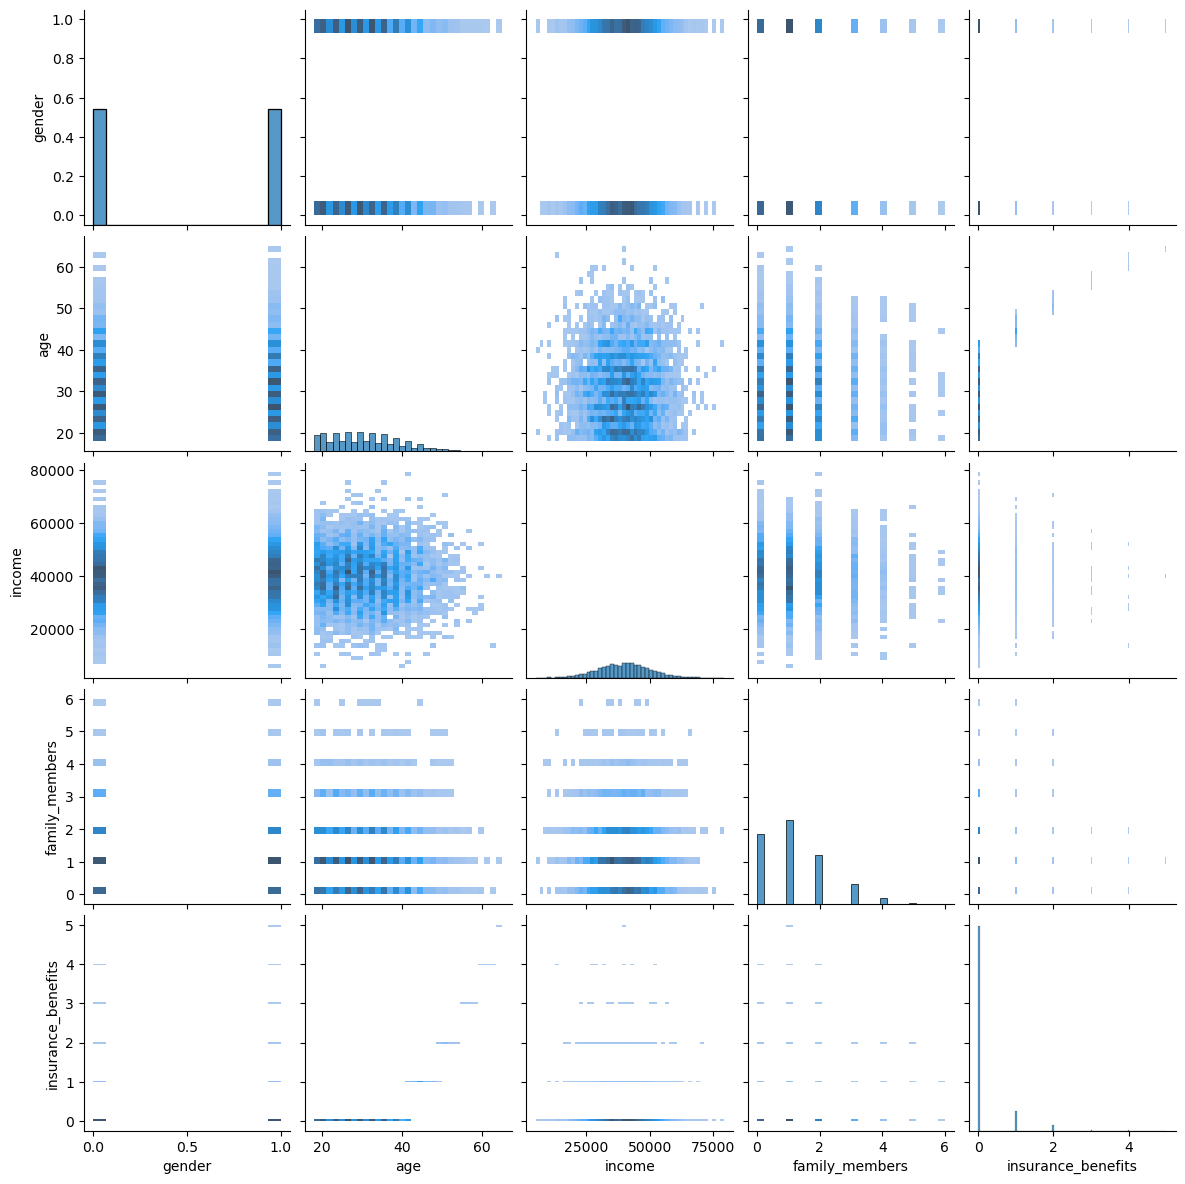

In [7]:
g = sns.pairplot(df, kind='hist')
g.fig.set_size_inches(12, 12)

Ok, é um pouco difícil identificar grupos óbvios (clusters), pois é difícil combinar várias variáveis simultaneamente (para analisar distribuições multivariadas). É aí que Álgebra Linear e Aprendizado de Máquina podem ser bastante úteis.

<Axes: >

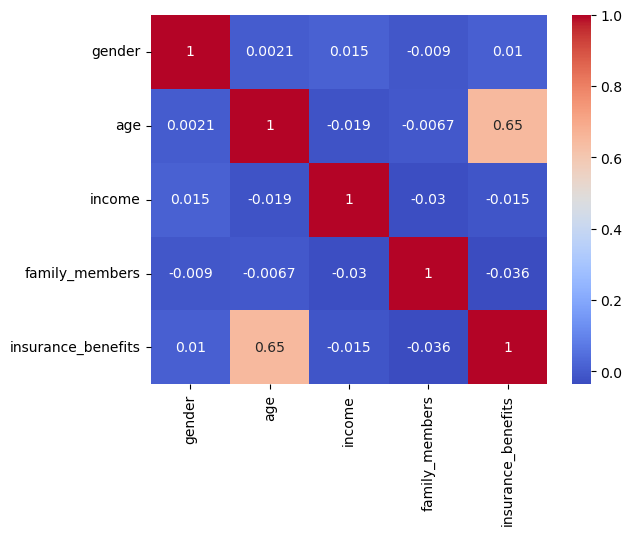

In [8]:
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')

array([[<Axes: title={'center': 'gender'}>,
        <Axes: title={'center': 'age'}>],
       [<Axes: title={'center': 'income'}>,
        <Axes: title={'center': 'family_members'}>],
       [<Axes: title={'center': 'insurance_benefits'}>, <Axes: >]],
      dtype=object)

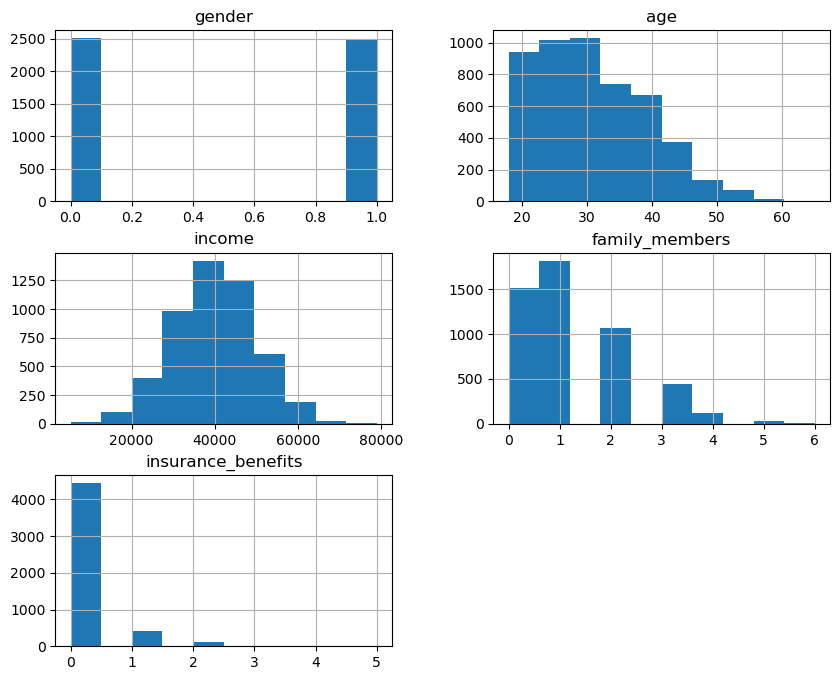

In [9]:
df.hist(figsize=(10,8))

- Apesar de apenas a variável idade apresentar correlação significativa com a variável alvo, as demais variáveis não serão descartadas neste momento.

- A análise de correlação considera apenas relações lineares e pode não capturar padrões mais complexos. Portanto, todas as variáveis serão mantidas para avaliação nos modelos de machine learning.

- Além disso, será necessário aplicar normalização devido à diferença de escala entre as variáveis, especialmente para algoritmos baseados em distância.

# Tarefa 1. Clientes Similares

Na linguagem de AM, é necessário desenvolver um procedimento que retorne k vizinhos mais próximos (objetos) para um determinado objeto com base na distância entre os objetos.

Você pode querer rever as seguintes lições (capítulo -> lição)
- Distância Entre Vetores -> Distância Euclidiana
- Distância Entre Vetores -> Distância de Manhattan

Para resolver a tarefa, podemos tentar diferentes métricas de distância.


Escreva uma função que retorne k vizinhos mais próximos para um n-ésimo objeto com base em uma métrica de distância especificada. O número de pagamentos de seguro recebidos não deve ser levado em consideração para esta tarefa. 

Você pode usar uma implementação pronta do algoritmo kNN do scikit-learn (verifique [o link](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.NearestNeighbors.html#sklearn.neighbors.NearestNeighbors)) ou usar a sua própria.

Teste-o para quatro combinações de dois casos
- Escalabilidade
  - os dados não são escalados
  - os dados escalados com o escalonador [MaxAbsScaler](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.MaxAbsScaler.html) 
- Métricas de distância
  - Euclidiana
  - Manhattan

Responda às perguntas:
- Os dados não escalados afetam o algoritmo kNN? Se sim, como isso acontece?
-Quão semelhantes são os resultados usando a métrica de distância de Manhattan (independentemente da escalabilidade)?

In [12]:
feature_names = ['gender', 'age', 'income', 'family_members']

In [13]:
def get_knn(df, n, k, metric):
    
    """
    Retorna os vizinhos mais próximos de k

    :param df: DataFrame pandas usado para encontrar objetos semelhantes dentro de
    :param n: número do objeto pelo qual os vizinhos mais próximos são procurados
    :param k: o número dos vizinhos mais próximos a serem retornados
    :param metric: nome da métrica de distância
    """

    nbrs = sklearn.neighbors.NearestNeighbors(n_neighbors=k, metric=metric)
    nbrs.fit(df[feature_names])
    nbrs_distances, nbrs_indices = nbrs.kneighbors([df.iloc[n][feature_names]], return_distance=True)
    
    df_res = pd.concat([
        df.iloc[nbrs_indices[0]], 
        pd.DataFrame(nbrs_distances.T, index=nbrs_indices[0], columns=['distance'])
        ], axis=1)
    
    return df_res


Escalando os dados

In [14]:
feature_names = ['gender', 'age', 'income', 'family_members']

transformer_mas = sklearn.preprocessing.MaxAbsScaler().fit(df[feature_names].to_numpy())

df_scaled = df.copy()
df_scaled.loc[:, feature_names] = transformer_mas.transform(df[feature_names].to_numpy())

C:\Users\ferna\AppData\Local\Temp\ipykernel_26204\760832288.py:6: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[0.63076923 0.70769231 0.44615385 ... 0.30769231 0.33846154 0.43076923]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_scaled.loc[:, feature_names] = transformer_mas.transform(df[feature_names].to_numpy())
C:\Users\ferna\AppData\Local\Temp\ipykernel_26204\760832288.py:6: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[0.16666667 0.16666667 0.         ... 0.33333333 0.5        0.16666667]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_scaled.loc[:, feature_names] = transformer_mas.transform(df[feature_names].to_numpy())


In [15]:
df_scaled.sample(5)

,gender,age,income,family_members,insurance_benefits
2100,0,0.569231,0.332911,0.333333,0
189,0,0.600000,0.521519,0.000000,0
1941,1,0.415385,0.568354,0.166667,0
4085,0,0.446154,0.802532,0.166667,0
3254,0,0.707692,0.310127,0.166667,1


Agora, vamos obter registros semelhantes para um determinado registro para cada combinação

In [16]:
get_knn(df, n=0, k=5, metric='euclidean')

c:\Users\ferna\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but NearestNeighbors was fitted with feature names
  warnings.warn(


,gender,age,income,family_members,insurance_benefits,distance
0,1,41,49600.0,1,0,0.000000
2022,1,41,49600.0,0,0,1.000000
1225,0,42,49600.0,0,1,1.732051
4031,1,44,49600.0,2,1,3.162278
3424,0,38,49600.0,0,0,3.316625


In [17]:
get_knn(df_scaled, n=0, k=5, metric='euclidean')

c:\Users\ferna\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but NearestNeighbors was fitted with feature names
  warnings.warn(


,gender,age,income,family_members,insurance_benefits,distance
0,1,0.630769,0.627848,0.166667,0,0.000000
2689,1,0.630769,0.634177,0.166667,0,0.006329
133,1,0.615385,0.636709,0.166667,0,0.017754
4869,1,0.646154,0.637975,0.166667,1,0.018418
3275,1,0.646154,0.651899,0.166667,1,0.028550


In [18]:
get_knn(df, n=0, k=5, metric='manhattan')

c:\Users\ferna\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but NearestNeighbors was fitted with feature names
  warnings.warn(


,gender,age,income,family_members,insurance_benefits,distance
0,1,41,49600.0,1,0,0.0
2022,1,41,49600.0,0,0,1.0
1225,0,42,49600.0,0,1,3.0
4031,1,44,49600.0,2,1,4.0
815,1,37,49600.0,2,0,5.0


In [19]:
get_knn(df_scaled, n=0, k=5, metric='manhattan')

c:\Users\ferna\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but NearestNeighbors was fitted with feature names
  warnings.warn(


,gender,age,income,family_members,insurance_benefits,distance
0,1,0.630769,0.627848,0.166667,0,0.000000
2689,1,0.630769,0.634177,0.166667,0,0.006329
133,1,0.615385,0.636709,0.166667,0,0.024245
4869,1,0.646154,0.637975,0.166667,1,0.025511
2103,1,0.630769,0.596203,0.166667,0,0.031646


Respostas para as perguntas

**Os dados não escalados afetam o algoritmo kNN? Se sim, como isso acontece?** 

Coloque sua resposta aqui.

- Sem normalização, a variável renda domina o cálculo de distância, fazendo com que os vizinhos encontrados tenham valores muito próximos ou idênticos de renda, independentemente das demais características.

- Após a normalização, todas as variáveis passam a contribuir de forma equilibrada, resultando em vizinhos mais semelhantes considerando múltiplas características.

- Portanto, a normalização é essencial para algoritmos baseados em distância, como o KNN.

**Quão semelhantes são os resultados usando a métrica de distância de Manhattan (independentemente da escalabilidade)?** 

Coloque sua resposta aqui.
- Utilizando a tecnica Manhattan, tivemos resultados bem similares a Euclideana, já que o resultado sem normalização falha pelo mesmo motivo (income muito divergente das outras métricas) e no caso dos dados normalizados, a diferença entre os métodos é pequena.

# Tarefa 2. É provável que o cliente receba um pagamento do seguro?

Com os pagamentos de seguro sendo mais do que zero como objetivo, avalie se a abordagem da classificação kNN pode ser melhor do que um modelo dummy.

Instruções:
- Construa um classificador baseado em kNN e meça sua qualidade com a métrica F1 para k=1..10 tanto para os dados originais quanto para os escalados. Seria interessante ver como k pode influenciar a métrica de avaliação e se a escalabilidade dos dados faz alguma diferença. Você pode usar uma implementação pronta do algoritmo de classificação kNN do scikit-learn (verifique [o link](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html)) ou usar a sua própria.
- Construa o modelo dummy, que é aleatório para este caso. Deve retornar com alguma probabilidade o valor "1". LVamos testar o modelo com quatro valores de probabilidade: 0, a probabilidade de fazer qualquer pagamento de seguro, 0,5, 1.

A probabilidade de fazer qualquer pagamento de seguro pode ser definida como

$$
P\{\text{pagamento de seguro recebido}= número de clientes que receberam qualquer pagamento de seguro}}{\text{número total de clientes}}.
$$

Divida os dados inteiros na proporção 70:30 para as partes de treinamento/teste.


In [20]:
# calcule a meta

df['insurance_benefits_received'] = (df['insurance_benefits'] > 0).astype(int)

In [21]:
# verifique o desequilíbrio de classe com value_counts()

df['insurance_benefits_received'].value_counts(normalize=True)


insurance_benefits_received
0    0.8872
1    0.1128
Name: proportion, dtype: float64

In [22]:
def eval_classifier(y_true, y_pred):
    
    f1_score = sklearn.metrics.f1_score(y_true, y_pred)
    print(f'F1: {f1_score:.2f}')
    
# se você tiver um problema com a linha a seguir, reinicie o kernel e execute o caderno novamente
    cm = sklearn.metrics.confusion_matrix(y_true, y_pred, normalize='all')
    print('Matriz de Confusão')
    print(cm)


In [23]:
# gerando saída de um modelo aleatório

def rnd_model_predict(P, size, seed=42):

    rng = np.random.default_rng(seed=seed)
    return rng.binomial(n=1, p=P, size=size)


In [24]:
for P in [0, df['insurance_benefits_received'].sum() / len(df), 0.5, 1]:

    print(f'A probabilidade: {P:.2f}')
    y_pred_rnd = rnd_model_predict(P, size=len(df))
        
    eval_classifier(df['insurance_benefits_received'], y_pred_rnd)
    
    print()


A probabilidade: 0.00
F1: 0.00
Matriz de Confusão
[[0.8872 0.    ]
 [0.1128 0.    ]]

A probabilidade: 0.11
F1: 0.12
Matriz de Confusão
[[0.7914 0.0958]
 [0.0994 0.0134]]

A probabilidade: 0.50
F1: 0.20
Matriz de Confusão
[[0.456  0.4312]
 [0.053  0.0598]]

A probabilidade: 1.00
F1: 0.20
Matriz de Confusão
[[0.     0.8872]
 [0.     0.1128]]



In [25]:
X = df[feature_names]
y = df['insurance_benefits_received']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=12345)

In [26]:
from sklearn.preprocessing import MaxAbsScaler

scaler = sklearn.preprocessing.MaxAbsScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [27]:
print("SEM ESCALA")
for k in range(1, 11):
    model = sklearn.neighbors.KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    
    print(f'k={k}')
    eval_classifier(y_test, y_pred)
    print()


print("COM ESCALA")
for k in range(1, 11):
    model = sklearn.neighbors.KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train_scaled, y_train)
    
    y_pred = model.predict(X_test_scaled)
    
    print(f'k={k}')
    eval_classifier(y_test, y_pred)
    print()

SEM ESCALA
k=1
F1: 0.60
Matriz de Confusão
[[0.87066667 0.02066667]
 [0.05266667 0.056     ]]

k=2
F1: 0.41
Matriz de Confusão
[[0.88733333 0.004     ]
 [0.08       0.02866667]]

k=3
F1: 0.41
Matriz de Confusão
[[0.87933333 0.012     ]
 [0.078      0.03066667]]

k=4
F1: 0.28
Matriz de Confusão
[[0.88866667 0.00266667]
 [0.09066667 0.018     ]]

k=5
F1: 0.27
Matriz de Confusão
[[0.88533333 0.006     ]
 [0.09066667 0.018     ]]

k=6
F1: 0.11
Matriz de Confusão
[[0.89       0.00133333]
 [0.102      0.00666667]]

k=7
F1: 0.11
Matriz de Confusão
[[0.88866667 0.00266667]
 [0.102      0.00666667]]

k=8
F1: 0.07
Matriz de Confusão
[[0.89133333 0.        ]
 [0.10466667 0.004     ]]

k=9
F1: 0.08
Matriz de Confusão
[[0.89133333 0.        ]
 [0.104      0.00466667]]

k=10
F1: 0.00
Matriz de Confusão
[[0.89133333 0.        ]
 [0.10866667 0.        ]]

COM ESCALA
k=1
F1: 0.97
Matriz de Confusão
[[0.88866667 0.00266667]
 [0.00466667 0.104     ]]

k=2
F1: 0.93
Matriz de Confusão
[[8.90666667e-01 6.66

- O modelo kNN apresentou desempenho significativamente superior ao modelo dummy (predizendo sempre 0, já que é o valor da maioria dos dados), especialmente após a normalização dos dados.

- A métrica F1 atingiu valores elevados (talvez até elevados demais, futuras verificações podem ser feitas), indicando excelente equilíbrio entre precisão e recall.

- Sem normalização, o desempenho foi drasticamente inferior, evidenciando a importância do escalonamento em algoritmos baseados em distância.

- Além disso, observou-se que valores menores de k tendem a maior sensibilidade, enquanto valores maiores tornam o modelo mais conservador.

In [28]:
df.duplicated().sum()

np.int64(153)

In [29]:
df.groupby(feature_names)['insurance_benefits_received'].mean().sort_values(ascending=False).head()

gender  age  income   family_members
0       55   42300.0  1                 1.0
        47   32800.0  0                 1.0
             38800.0  0                 1.0
             37900.0  2                 1.0
                      0                 1.0
Name: insurance_benefits_received, dtype: float64

- Foi identificado que o conjunto de dados contém registros duplicados (~3% dos dados), o que pode favorecer modelos baseados em instâncias como o kNN.

- Além disso, algumas combinações de variáveis apresentam comportamento determinístico em relação à variável alvo, ou seja, sempre resultam no mesmo valor. Isso indica que o problema possui alta separabilidade no espaço de atributos.

- Esses fatores ajudam a explicar o alto desempenho do modelo, especialmente após a normalização dos dados.

# Tarefa 3. Regressão (com Regressão Linear)

Com os pagamentos de seguro como objetivo, avalie qual seria o REQM para um modelo de Regressão Linear.

Construa sua própria implementação de Regressão Linear. Para isso, lembre-se de como a solução da tarefa de regressão linear é formulada em termos de Álgebra linear. Verifique o REQM para os dados originais e os escalados. Você pode ver alguma diferença no REQM entre esses dois casos?

Vamos denotar
- $X$ — matriz de características, cada linha é um caso, cada coluna é uma característica, a primeira coluna consiste em unidades
- $y$ — objetivo (um vetor)
- $\hat{y}$ — objetivo estimado (um vetor)
- $w$ — vetor de peso

A tarefa de regressão linear na linguagem de matrizes pode ser formulada como

$$
y = Xw
$$

O objetivo do treinamento, então, é encontrar os $w$ que minimizaria a distância L2 (EQM) entre $Xw$ e $y$:

$$
\min_w d_2(Xw, y) \quad \text{or} \quad \min_w \text{MSE}(Xw, y)
$$

Parece que há uma solução analítica para a questão acima:

$$
w = (X^T X)^{-1} X^T y
$$

A fórmula acima pode ser usada para encontrar os pesos $w$ e o último pode ser usado para calcular valores preditos

$$
\hat{y} = X_{val}w
$$


Divida todos os dados na proporção 70:30 para as partes de treinamento/validação. Use a métrica REQM para a avaliação do modelo.

In [31]:
class MyLinearRegression:
    
    def __init__(self):
        
        self.weights = None
    
    def fit(self, X, y):
        
        # somando as unidades
        X2 = np.append(np.ones([len(X), 1]), X, axis=1)
        self.weights = np.linalg.inv(X2.T @ X2) @ X2.T @ y

    def predict(self, X):
        
        # somando as unidades
        X2 = np.append(np.ones([len(X), 1]), X, axis=1)
        y_pred = X2 @ self.weights
        
        return y_pred

In [39]:
def eval_regressor(y_true, y_pred):
    
    rmse = math.sqrt(sklearn.metrics.mean_squared_error(y_true, y_pred))
    print(f'REQM: {rmse:.2f}')
    
    r2_score = math.sqrt(sklearn.metrics.r2_score(y_true, y_pred))
    print(f'R2: {r2_score:.2f}')    


In [40]:
X = df[['age', 'gender', 'income', 'family_members']].to_numpy()
y = df['insurance_benefits'].to_numpy()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=12345)

lr = MyLinearRegression()

lr.fit(X_train, y_train)
print(lr.weights)

y_test_pred = lr.predict(X_test)
eval_regressor(y_test, y_test_pred)

[-9.43539012e-01  3.57495491e-02  1.64272726e-02 -2.60743659e-07
 -1.16902127e-02]
REQM: 0.34
R2: 0.66


In [41]:
X_scaled = scaler.fit_transform(df[['age', 'gender', 'income', 'family_members']].to_numpy())
y = df['insurance_benefits'].to_numpy()

X_train_scaled, X_test_scaled, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.3, random_state=12345
)

lr_scaled = MyLinearRegression()
lr_scaled.fit(X_train_scaled, y_train)
print(lr_scaled.weights)

y_test_pred_scaled = lr_scaled.predict(X_test_scaled)
eval_regressor(y_test, y_test_pred_scaled)

[-0.94353901  2.32372069  0.01642727 -0.02059875 -0.07014128]
REQM: 0.34
R2: 0.66


- Foi implementada uma regressão linear utilizando a solução analítica baseada em álgebra linear.

- Os resultados mostraram que o REQM e o R² foram praticamente idênticos tanto para os dados originais quanto para os dados escalados. Isso confirma que a regressão linear não é sensível à escala das variáveis em termos de desempenho preditivo, embora os coeficientes do modelo sejam ajustados de acordo com a escala dos dados.

- O modelo apresentou um REQM de aproximadamente 0.34 e um R² de aproximadamente 0.66, indicando que é capaz de explicar uma parcela significativa da variabilidade do número de pagamentos de seguro, embora não capture completamente toda a complexidade do problema.

# Tarefa 4. Ofuscando dados

É melhor ofuscar os dados multiplicando as características numéricas (lembre-se, elas podem ser vistos como a matriz $X$) por uma matriz invertível $P$. 

$$
X' = X \times P
$$

Tente fazer isso e verifique como os valores das características ficarão após a transformação. Aliás, a invertibilidade é importante aqui, portanto, certifique-se de que $P$ seja realmente invertível.

Você pode querer revisar a lição 'Matrizes e Operações com Matrizes -> Multiplicação de Matrizes' para relembrar a regra de multiplicação de matrizes e sua implementação com NumPy.


In [ ]:
personal_info_column_list = ['gender', 'age', 'income', 'family_members']
df_pn = df[personal_info_column_list]

In [ ]:
X = df_pn.to_numpy()

Gerando uma matriz $P$ aleatória.

In [ ]:
rng = np.random.default_rng(seed=42)
P = rng.random(size=(X.shape[1], X.shape[1]))


Verificando se a matriz $P$ é invertível

Você consegue adivinhar a idade ou a renda dos clientes após a transformação?

Você pode recuperar os dados originais de $X′$ se souber $P$? Tente verificar isso com cálculos movendo $P$ do lado direito da fórmula acima para o esquerdo. As regras da multiplicação de matrizes são realmente úteis aqui

Imprima todos os três casos para alguns clientes
- Os dados originais
- O transformado
- O invertido (recuperado)


Você provavelmente pode ver que alguns valores não são exatamente iguais aos dos dados originais. Qual pode ser a razão disso?

## Provas de que a ofuscação de dados pode funcionar com a Regressão Linear

A tarefa de regressão foi resolvida com regressão linear neste projeto. Sua próxima tarefa é provar analiticamente que o método de ofuscação fornecido não afetará a regressão linear em termos de valores preditos, ou seja, seus valores permanecerão os mesmos. Você acredita nisso? Bem, você não precisa acreditar, você deve provar isso!

Assim, os dados são ofuscados e há $X \ P$ em vez de apenas X agora. Consequentemente, existem outros pesos $w_P$ como
$$
w = (X^T X)^{-1} X^T y \quad \Rightarrow \quad w_P = [(XP)^T XP]^{-1} (XP)^T y
$$

Como  $w$ e $w_P$ seriam ligados se você simplificasse a fórmula para $w_P$ acima? 

Quais seriam os valores previstos com $w_P$? 

O que isso significa para a qualidade da regressão linear se você medir com REQM?

Verifique o Apêndice B Propriedades das Matrizes no final do caderno. Existem fórmulas úteis lá!

Nenhum código é necessário nesta seção, apenas explicação analítica!


**Resposta**

**Prova analítica**

## Teste de regressão linear com ofuscação de dados

Agora, vamos provar que a Regressão Linear pode funcionar computacionalmente com a transformação de ofuscação escolhida.

Crie um procedimento ou uma classe que execute a Regressão Linear opcionalmente com a ofuscação. Você pode usar uma implementação pronta de Regressão Linear do scikit-learn ou sua própria.

Execute a Regressão Linear para os dados originais e os ofuscados, compare os valores previstos e os valores da métrica $R^2$ do REQM. Há alguma diferença?


**Procedimento**

- Crie uma matriz quadrada $P$ de números aleatórios.
- Verifique se é invertível. Caso contrário, repita o primeiro ponto até obtermos uma matriz invertível.
- <! seu comentário aqui!>
- Use $XP$ como a nova matriz de características


# Conclusões

# Checklist

Digite 'x' para verificar. Em seguida, pressione Shift + Enter.

- [x]  O Jupyter Notebook está aberto.
- [ ]  O código está livre de erros
- [ ]  As células são organizadas em ordem de lógica e execução
- [ ]  A tarefa 1 foi executada
    - [ ]  Existe o procedimento que pode retornar k clientes semelhantes a um determinado cliente
    - [ ]  O procedimento é testado para todas as quatro combinações propostas
    - [ ]  As perguntas sobre a escala/distâncias são respondidas
- [ ]  A tarefa 2 foi executada
    - [ ]  O modelo de classificação aleatória é construído e testado para todos os níveis de probabilidade
    - [ ]  O modelo de classificação kNN é construído e testado tanto para os dados originais quanto para os escalados, a métrica F1 é calculada.
- [ ]  A tarefa 3 foi executada
    - [ ]  A solução de regressão linear é implementada com operações matriciais.
    - [ ]  O REQM é calculado para a solução implementada.
- [ ]  A tarefa 4 foi executada
    - [ ]  Os dados são ofuscados com uma matriz P aleatória e invertível
    - [ ]  Os dados ofuscados são recuperados, alguns exemplos são impressos
    - [ ]  A prova analítica de que a transformação não afeta o REQM é fornecida
    - [ ]  A prova computacional de que a transformação não afeta o REQM é fornecida
- [ ]  As conclusões foram feitas


# Apêndices

## Apêndice A: Escrevendo Fórmulas em Notebooks Jupyter


Você pode escrever fórmulas em seu Jupyter Notebook em uma linguagem de marcação de texto fornecida por um sistema de publicação de alta qualidade chamado $\LaTeX$ (pronuncia-se "Lah-tech"), e elas se parecerão com fórmulas em livros didáticos.

Para colocar uma fórmula em um texto, coloque o cifrão ($) antes e depois do texto da fórmula, por exemplo $\frac{1}{2} \times \frac{3}{2} = \frac{3}{4}$ or $y = x^2, x \ge 1$.

Se uma fórmula deve estar em seu próprio parágrafo, coloque o cifrão duplo ($$) antes e depois do texto da fórmula, por exemplo

$$
\bar{x} = \frac{1}{n}\sum_{i=1}^{n} x_i.
$$

A linguagem de marcação do [LaTeX](https://en.wikipedia.org/wiki/LaTeX) é muito popular entre as pessoas que usam fórmulas em seus artigos, livros e textos. Pode ser complexo, mas o básico é fácil. Confira esta [folha de dicas](http://tug.ctan.org/info/undergradmath/undergradmath.pdf) de duas páginas  para aprender a compor as fórmulas mais comuns.


## Apêndice B: Propriedades das Matrizes

Matrizes têm muitas propriedades em Álgebra Linear. Algumas delas estão listadas aqui, o que pode ajudar na prova analítica deste projeto.

<table>
<tr>
<td>Distributividade</td><td>$A(B+C)=AB+AC$</td>
</tr>
<tr>
<td>Não-comutatividade</td><td>$AB \neq BA$</td>
</tr>
<tr>
<td>Propriedade associativa da multiplicação</td><td>$(AB)C = A(BC)$</td>
</tr>
<tr>
<td>Propriedade de identidade multiplicativa</td><td>$IA = AI = A$</td>
</tr>
<tr>
<td></td><td>$A^{-1}A = AA^{-1} = I$
</td>
</tr>    
<tr>
<td></td><td>$(AB)^{-1} = B^{-1}A^{-1}$</td>
</tr>    
<tr>
<td>Reversividade da transposição de um produto de matrizes,</td><td>$(AB)^T = B^TA^T$</td>
</tr>    
</table>
